In [1]:
import os
from pinecone import Pinecone
from dotenv import load_dotenv
from langchain_ollama import OllamaEmbeddings
import pickle
from langchain_community.retrievers import PineconeHybridSearchRetriever
import pandas as pd
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
load_dotenv()
api_key = os.getenv("PINECONE_API_KEY")

In [3]:
embeddings = OllamaEmbeddings(
    model="qwen3-embedding:8b",
    base_url=os.environ.get("OLLAMA_URL", "http://localhost:11434"),
)

In [5]:
def parse_verse_list_str(s: str):
    return [int(x) for x in re.findall(r"\d+", str(s))]

def chunk_hits_any_ayah(chunk_meta: dict, gt_surah: int, gt_ayah_list) -> bool:
    try:
        surah = int(chunk_meta.get("surah_no"))
        a0 = int(chunk_meta.get("ayah_start"))
        a1 = int(chunk_meta.get("ayah_end"))
    except Exception:
        return False

    if surah != int(gt_surah):
        return False

    for ay in gt_ayah_list:
        if a0 <= int(ay) <= a1:
            return True
    return False


def eval_hit_at_k(
    qa_df: pd.DataFrame,
    retriever,
    k: int = 10,
    alpha: float = 0.7,
    question_col: str = "question",
    gt_surah_col: str = "surah_no",
    gt_verses_col: str = "verses",
):
    if hasattr(retriever, "top_k"):
        retriever.top_k = k
    if hasattr(retriever, "alpha"):
        retriever.alpha = alpha

    rows = []
    hits = 0

    for idx, row in tqdm(qa_df.iterrows(), total=len(qa_df), desc=f"Evaluating Hit@{k}"):
        q = str(row[question_col])
        gt_surah = int(row[gt_surah_col])
        gt_verses = parse_verse_list_str(row[gt_verses_col])

        docs = retriever.invoke(q)

        hit = False
        hit_rank = None
        hit_doc = None

        for rank, d in enumerate(docs, start=1):
            if chunk_hits_any_ayah(d.metadata, gt_surah, gt_verses):
                hit = True
                hit_rank = rank
                hit_doc = d
                break

        hits += int(hit)

        rows.append({
            "row_idx": idx,
            "question": q,
            "gt_surah": gt_surah,
            "gt_verses": gt_verses,
            "hit": hit,
            "hit_rank": hit_rank,
            "hit_doc_meta": hit_doc.metadata if hit_doc else None,
        })

    report = pd.DataFrame(rows)
    hit_at_k = hits / len(qa_df) if len(qa_df) else 0.0
    return hit_at_k, report


In [6]:
qa_df = pd.read_csv("question_answering.csv")
qa_df

,Unnamed: 0,question_en,answer_en,chapter_no,verse_list
0,0,What is the only book that is free from any do...,This is the Book of Allah . The evidence: 'Thi...,2,[1 2]
1,1,Are the fruits of paradise similar to the frui...,"Yes, and the evidence: 'And give good news to ...",2,[25]
2,2,How many deaths and how many lives do humans h...,"And you were dead, and He gave you life, then ...",2,[28]
3,3,How many heavens are there?,He it is Who created for you all that is in th...,2,[29]
4,4,"What did Adam learn from Allah , which was no...","He taught Adam the names of all things, then H...",2,[31]
...,...,...,...,...,...
1186,1218,Who is the wife of Ibrahim who laughed when s...,She is Sarah.,11,[71]
1187,1219,"Indeed, Abraham was forbearing, often turning ...","Abraham, peace be upon him, is patient, dislik...",11,[75]
1188,1220,Why did Lot grieve when the guests arrived at...,He feared for them because they were handsome-...,11,[77]
1189,1221,"What does Lut mean by his statement, 'If only...","If I had power and supporters among you, or if...",11,[80]


In [30]:
pc = Pinecone(api_key=api_key)
index_ebn = pc.Index("quran-tafseer-ebn")

In [31]:
with open("bm25_quran_ebn.pkl", "rb") as f:
    bm25_ebn = pickle.load(f)

In [32]:
NAMESPACE = "quran_jal"

retriever_ebn = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25_ebn,
    index=index_ebn,
    namespace=NAMESPACE,
    top_k=10,
    alpha=0.7,
)

docs = retriever_ebn.invoke("What does the Quran say about patience?")
print(len(docs))
print(docs[0].metadata)
print(docs[0].page_content[:400])


10
{'ayah_end': 154.0, 'ayah_start': 153.0, 'surah_no': 2.0, 'score': 0.578527093}
ayah: O believers! Seek comfort in patience and prayer. Allah is truly with those who are patient. Never say that those martyred in the cause of Allah are dead-in fact, they are alive! But you do not perceive it.
tafseer: Allah commands patience and prayer to help the servant in both bounty and calamity. If a believer receives a blessing, gratitude benefits him; if he faces hardship, patience bene


In [33]:
alphas = [0.3, 0.5, 0.7, 0.9]
ks = [5, 10, 15, 20]

results_ebn = []
reports_ebn = {}

for k in ks:
    for alpha in alphas:
        hit_at_k, report = eval_hit_at_k(
            qa_df=qa_df,
            retriever=retriever_ebn,
            k=k,
            alpha=alpha,
            question_col="question_en",
            gt_surah_col="chapter_no",
            gt_verses_col="verse_list",
        )

        results_ebn.append({
            "k": k,
            "alpha": alpha,
            "hit_at_k": float(hit_at_k),
            "hits": int(report["hit"].sum()),
            "misses": int((~report["hit"]).sum()),
            "n": int(len(report)),
        })

        reports_ebn[(k, alpha)] = report

results_df_ebn = pd.DataFrame(results_ebn).sort_values(["k", "alpha"]).reset_index(drop=True)
display(results_df_ebn)

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@10:   0%|          | 0/1191 [00:00<?, ?it/s]

...

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

,k,alpha,hit_at_k,hits,misses,n
0,5,0.3,0.621327,740,451,1191
1,5,0.5,0.630563,751,440,1191
2,5,0.7,0.619647,738,453,1191
3,5,0.9,0.573468,683,508,1191
4,10,0.3,0.680940,811,380,1191
5,10,0.5,0.701931,836,355,1191
6,10,0.7,0.693535,826,365,1191
7,10,0.9,0.647355,771,420,1191
8,15,0.3,0.712846,849,342,1191
9,15,0.5,0.732997,873,318,1191


---

In [34]:
pc = Pinecone(api_key=api_key)
index_jal = pc.Index("quran-tafseer-jal")

In [35]:
with open("bm25_quran_jal.pkl", "rb") as f:
    bm25_jal = pickle.load(f)

In [36]:
NAMESPACE = "quran_jal"

retriever_jal = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25_jal,
    index=index_jal,
    namespace=NAMESPACE,
    top_k=15,
    alpha=0.7,
)

docs = retriever_jal.invoke("What does the Quran say about patience?")
print(len(docs))
print(docs[0].metadata)
print(docs[0].page_content[:400])


15
{'ayah_end': 153.0, 'ayah_start': 153.0, 'surah_no': 2.0, 'score': 0.632772565}
ayah: o believers! seek comfort in patience and prayer. allah is truly with those who are patient.
tafseer: o you who believe seek help regarding the hereafter through patience in obedience and afflictions and prayer he singles it out for mention on account of its frequency and its greatness; surely god is with the patient helping them.


In [37]:
alphas = [0.3, 0.5, 0.7, 0.9]
ks = [5, 10, 15, 20]

results_jal = []
reports_jal = {}

for k in ks:
    for alpha in alphas:
        hit_at_k, report = eval_hit_at_k(
            qa_df=qa_df,
            retriever=retriever_jal,
            k=k,
            alpha=alpha,
            question_col="question_en",
            gt_surah_col="chapter_no",
            gt_verses_col="verse_list",
        )

        results_jal.append({
            "k": k,
            "alpha": alpha,
            "hit_at_k": float(hit_at_k),
            "hits": int(report["hit"].sum()),
            "misses": int((~report["hit"]).sum()),
            "n": int(len(report)),
        })

        reports_jal[(k, alpha)] = report

results_df_jal = pd.DataFrame(results_jal).sort_values(["k", "alpha"]).reset_index(drop=True)
display(results_df_jal)

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@5:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@10:   0%|          | 0/1191 [00:00<?, ?it/s]

...

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

Evaluating Hit@20:   0%|          | 0/1191 [00:00<?, ?it/s]

,k,alpha,hit_at_k,hits,misses,n
0,5,0.3,0.623846,743,448,1191
1,5,0.5,0.661629,788,403,1191
2,5,0.7,0.689337,821,370,1191
3,5,0.9,0.677582,807,384,1191
4,10,0.3,0.673384,802,389,1191
5,10,0.5,0.707809,843,348,1191
6,10,0.7,0.722082,860,331,1191
7,10,0.9,0.724601,863,328,1191
8,15,0.3,0.698573,832,359,1191
9,15,0.5,0.733837,874,317,1191


---

In [41]:
results_df_jal["tafseer"] = "Jalalayn"
results_df_ebn["tafseer"] = "IbnKathir"

df = pd.concat([results_df_jal, results_df_ebn], ignore_index=True)

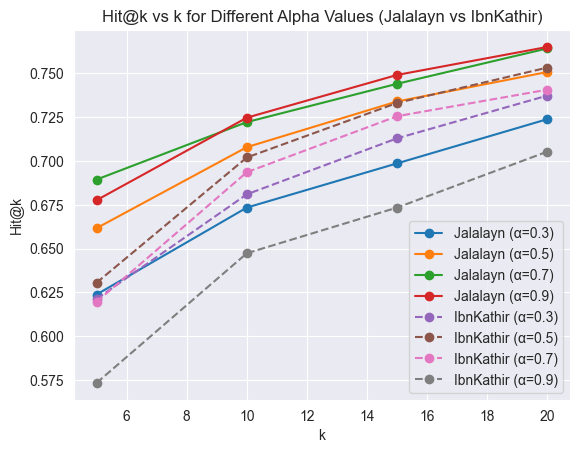

In [42]:
plt.figure()

tafseers = df["tafseer"].unique()
alphas = sorted(df["alpha"].unique())

for tafseer in tafseers:
    for alpha in alphas:
        subset = df[(df["tafseer"] == tafseer) & (df["alpha"] == alpha)]
        subset = subset.sort_values("k")

        if subset.empty:
            continue

        linestyle = "-" if tafseer == tafseers[0] else "--"

        plt.plot(
            subset["k"],
            subset["hit_at_k"],
            marker="o",
            linestyle=linestyle,
            label=f"{tafseer} (α={alpha})"
        )

plt.xlabel("k")
plt.ylabel("Hit@k")
plt.title("Hit@k vs k for Different Alpha Values (Jalalayn vs IbnKathir)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
NAMESPACE = "quran_jal"

retriever_jal = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25_jal,
    index=index_jal,
    namespace=NAMESPACE,
    top_k=20,
    alpha=0.9,
)



In [47]:
def measure_retrieval_lengths(qa_df, retriever, question_col="question_en"):
    rows = []

    # ensure we retrieve 20 once
    retriever.top_k = 20

    for _, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        q = str(row[question_col])
        docs = list(retriever.invoke(q) or [])

        docs_15 = docs[:15]
        docs_20 = docs[:20]

        chars_15 = sum(len(d.page_content) for d in docs_15)
        chars_20 = sum(len(d.page_content) for d in docs_20)

        words_15 = sum(len(d.page_content.split()) for d in docs_15)
        words_20 = sum(len(d.page_content.split()) for d in docs_20)

        rows.append({
            "chars_15": chars_15,
            "chars_20": chars_20,
            "words_15": words_15,
            "words_20": words_20,
        })

    df = pd.DataFrame(rows)

    summary = pd.DataFrame({
        "k": [15, 20],
        "mean_chars": [df["chars_15"].mean(), df["chars_20"].mean()],
        "median_chars": [df["chars_15"].median(), df["chars_20"].median()],
        "p95_chars": [
            np.percentile(df["chars_15"], 95),
            np.percentile(df["chars_20"], 95),
        ],
        "mean_words": [df["words_15"].mean(), df["words_20"].mean()],
        "median_words": [df["words_15"].median(), df["words_20"].median()],
    })

    return df, summary

In [49]:
length_df_jal, summary_jal = measure_retrieval_lengths(
    qa_df=qa_df,
    retriever=retriever_jal,
)

  0%|          | 0/1191 [00:00<?, ?it/s]

In [50]:
summary_jal

,k,mean_chars,median_chars,p95_chars,mean_words,median_words
0,15,6436.237615,5865.0,11500.0,1175.378673,1069.0
1,20,8436.642317,7836.0,14739.0,1540.689337,1433.0
